In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
#Load Auto MPG Dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)

#Display first five rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [12]:
#Separate input and output
x = df[['displacement']]
y = df['mpg']

#Check missing values
print("Missing values in ", x.isnull().sum())
print("Missing values in mpg: ", y.isnull().sum())

Missing values in  displacement    0
dtype: int64
Missing values in mpg:  0


In [15]:
#Remove rows containing missing values
data = df[['displacement', 'mpg']].dropna()

#Update input and output
x = data[['displacement']]
y = data['mpg']

#Display the selected data
print("Feature: ")
print(x.head())

print("\nTarget: ")
print(y.head())

Feature: 
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target: 
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


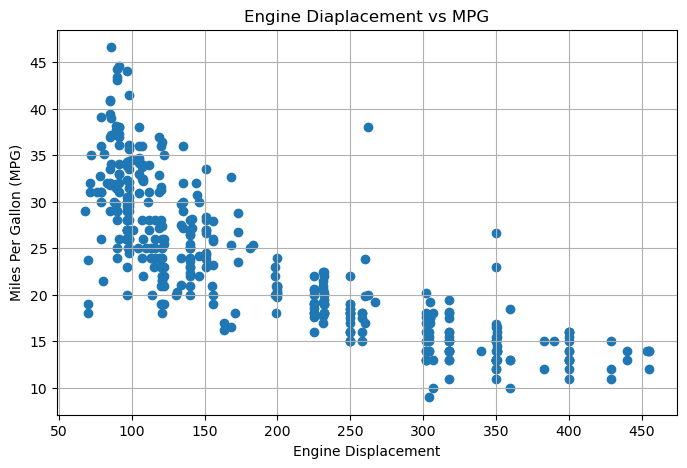

In [17]:
plt.figure(figsize = (8, 5))

plt.scatter(x, y)

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Engine Diaplacement vs MPG")

plt.grid(True)
plt.show()

In [20]:
#Split the dataset
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

print("Training samples: ", len(x_train))
print("Testing samples: ", len(x_test))    

Training samples:  318
Testing samples:  80


In [23]:
#Create Linear Regression Model
linear_model = LinearRegression()

#Train the model
linear_model.fit(x_train, y_train)

#Predict on test data
y_pred_linear = linear_model.predict(x_test)

In [25]:
#Calculate MSE
mse_linear = mean_squared_error(y_test, y_pred_linear)

#Calculate R-squared
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("--------------------")
print("MSE: ", mse_linear)
print("R-squared: ", r2_linear)

Linear Regression Results
--------------------
MSE:  18.102543998358946
R-squared:  0.6633114869465595


In [58]:
#Store results
results = []

#Store polynomial models for plotting
polynomial_models = {}

#Add Linear Regression Results
results.append({
    'Model': 'Linear Regression',
    'Degree':1,
    'MSE':mse_linear,
    'R-Squared': r2_linear
})

#Try polynomial degrees from 2 to 5
for degree in range(2, 6):

    #Create polynomial features
    poly = PolynomialFeatures(degree=degree)

    #Transform training and testing data
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)

    #Create Linear Regression Model
    poly_model = LinearRegression()
    
    #Train Polynomial Regression Model
    poly_model.fit(x_train_poly, y_train)
    
    #Make Predictions
    y_pred_poly = poly_model.predict(x_test_poly)
    
    #Calculate Evaluation Metrics
    mse = mean_squared_error(y_test, y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)
    
    #Store Results
    results.append({
        'Model': 'Polynomial Regression',
        'Degree': degree,
        'MSE': mse,
        'R-Squared': r2
    })

#Store model and polynomial transformer
    polynomial_models[degree] = {
        'poly': poly,
        'model': poly_model
    }

#Convert results into DataFrame
results_df = pd.DataFrame(results)

#Display Results
results_df

,Model,Degree,MSE,R-Squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


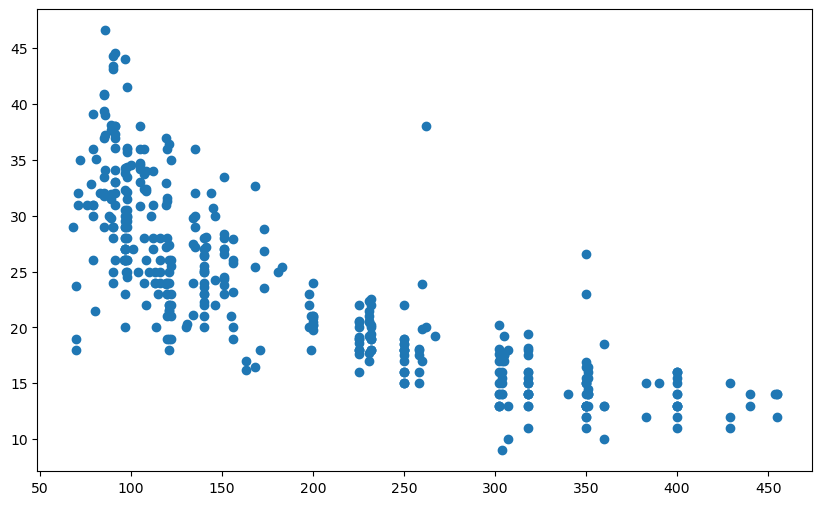

In [47]:
x_plot = pd.DataFrame({
    'displacement' : np.linspace(
        x['displacement'].min(),
        x['displacement'].max(),
        300
    )
})

plt.figure(figsize = (10, 6))

plt.scatter(
    x['displacement'],
    y,

    label = 'Actual Data'
)

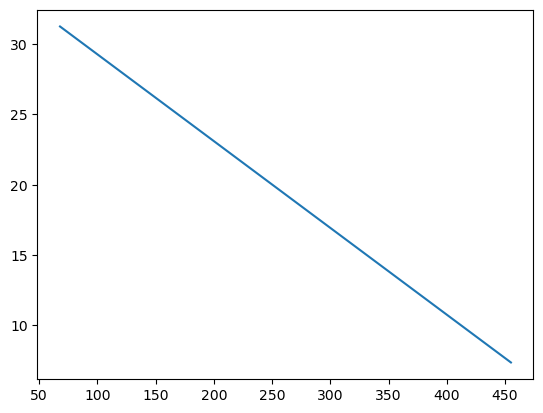

In [48]:
#--------------------
#Plot Linear Regression
#--------------------
y_plot_linear = linear_model.predict(x_plot)

plt.plot(
    x_plot['displacement'],
    y_plot_linear,
    label = 'Linear Regression'
)

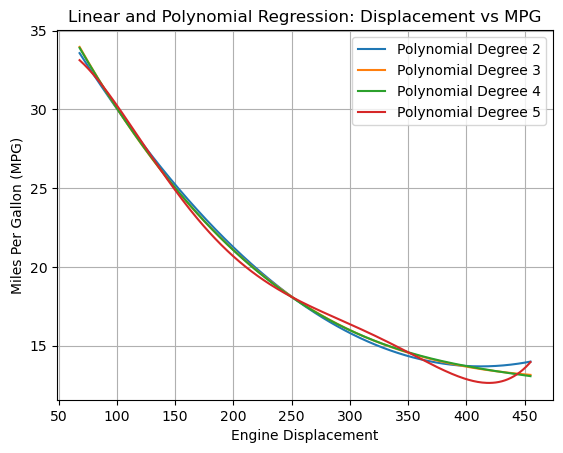

In [59]:
#Plot Polynomial Regression
#Degrees 2 to 5
#--------------------
for degree in range(2, 6):

    #Retrieved stored transformer and model
    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']

    #Transform smooth x values
    x_plot_poly = poly.transform(x_plot)

    #Predict
    y_plot_poly = poly_model.predict(x_plot_poly)

    #Plot Curve
    plt.plot(
        x_plot['displacement'],
        y_plot_poly,
        label = f'Polynomial Degree {degree}'
    )

plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallon (MPG)')

plt.title(
    'Linear and Polynomial Regression: Displacement vs MPG'
)

plt.legend()
plt.grid(True)
plt.show()

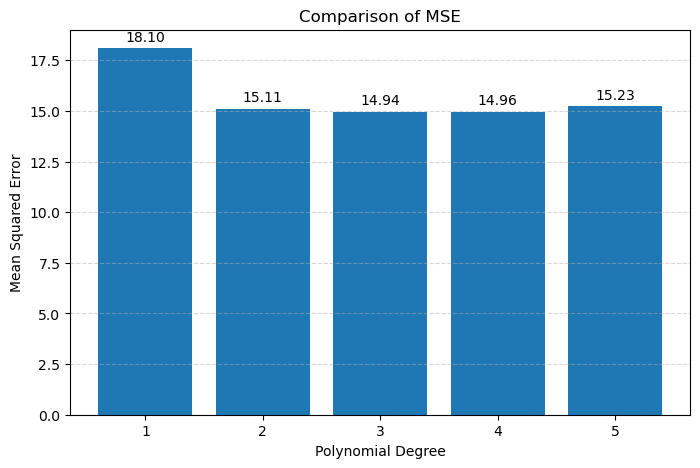

In [64]:
import matplotlib.pyplot as plt
plt.figure(figsize = (8, 5))
bars = plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)

#Add labels above bars
plt.bar_label(bars, fmt = '%.2f', padding = 3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.show()

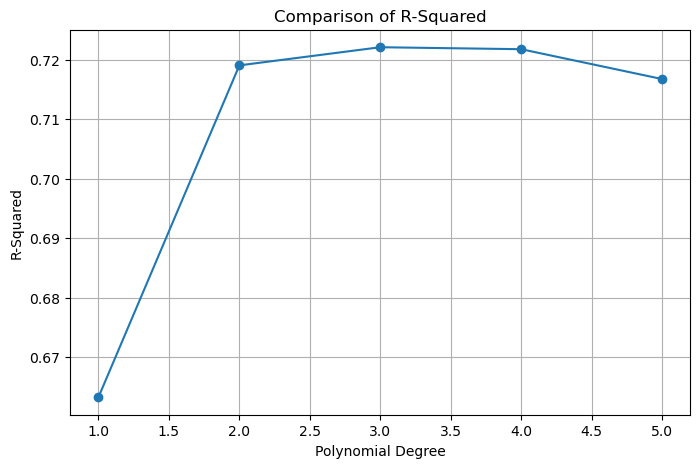

In [66]:
plt.figure(figsize = (8, 5))

plt.plot(
    results_df['Degree'],
    results_df['R-Squared'],
    marker = 'o'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R-Squared")
plt.title("Comparison of R-Squared")

plt.grid(True)
plt.show()    